# Bias-Variance Tradeoff

The **Bias-Variance Tradeoff** is one of the most critical concepts in machine learning. It provides a framework for understanding and diagnosing model errors, guiding us toward selecting an optimally complex model.

When we train a machine learning model, our goal is to minimize the total prediction error. This total error can be broken down into three main components:

$$\text{Total Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

### Bias

**Bias** is the error introduced by approximating a real-world problem (which may be complex) with a simplified model (e.g., assuming linearity when the relationship is non-linear).

  * **High Bias (Underfitting):** The model is too simple (e.g., a linear model on complex data) and consistently misses the relevant relations between features and target output. It performs poorly on both training and test data.
  * **Low Bias:** The model is flexible and accurately captures the true underlying relationship in the data.

### Variance

**Variance** is the sensitivity of the model's predictions to small fluctuations in the training data. It measures how much the model's output would change if we trained it on a different subset of the data.

  * **High Variance (Overfitting):** The model is too complex and learns the noise and specific patterns of the training data exceptionally well. It performs extremely well on the training data but poorly on the unseen test data.
  * **Low Variance:** The model is relatively stable across different training datasets.

### Irreducible Error

This is the **noise** in the data itself (e.g., random measurement errors). No matter how good our model is, this error cannot be reduced.


## Demonstration with Polynomial Regression

We'll use a synthetic dataset and different polynomial degrees to demonstrate how model complexity affects bias and variance.

### Setup and Data Generation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Set a random seed for reproducibility
np.random.seed(42)

# 1. Generate synthetic data
# The true function is sin(x) + noise
X = np.linspace(0, 10, 50)
y_true = np.sin(X)
noise = np.random.normal(0, 0.5, 50)
y = y_true + noise

# Reshape X for Scikit-learn
X = X.reshape(-1, 1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Comparing Models of Varying Complexity

We will train three models: a simple linear model (Degree 1), a well-fitted model (Degree 4), and a highly complex model (Degree 15).

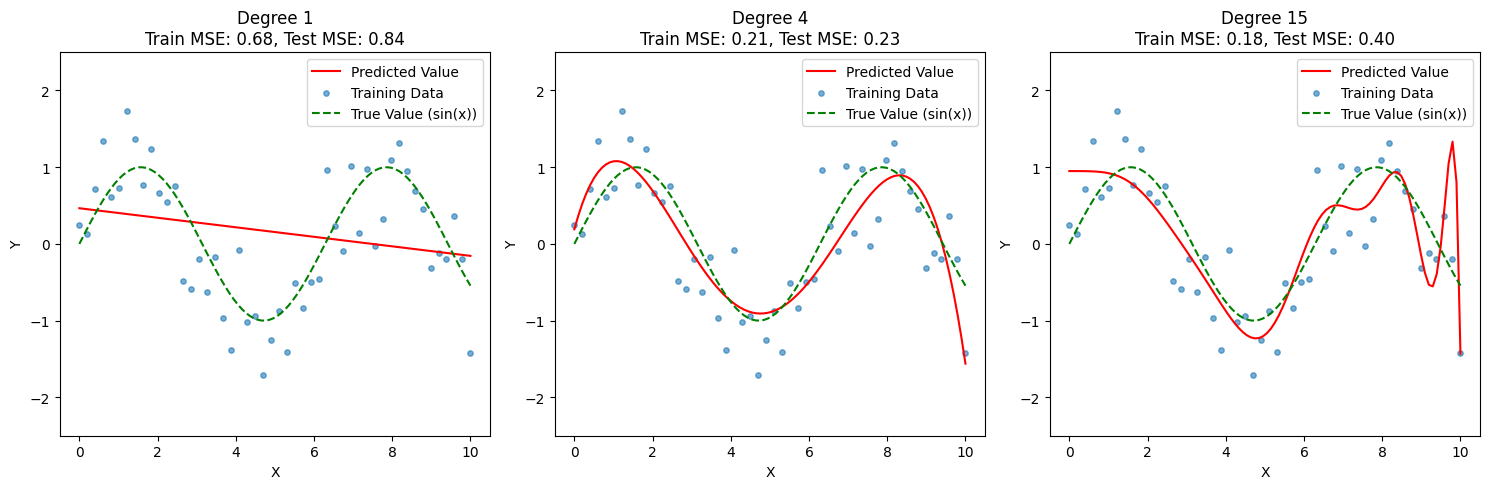

In [2]:
# List of polynomial degrees (model complexity)
degrees = [1, 4, 15]
test_errors = []
train_errors = []

# Define a plotting range
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    # Create a polynomial features
    poly_feature = PolynomialFeatures(degree, include_bias=False)
    poly_feature.fit(X_train) # Fit the training feature

    # Generate polynomial feature for train and test sets
    X_train_poly = poly_feature.transform(X_train)
    X_test_poly = poly_feature.transform(X_test)
    X_plot_poly = poly_feature.transform(X_plot)
    
    # Instantiate the Linear Regression model
    model = LinearRegression()

    # Train the model
    model.fit(X_train_poly, y_train)

    # Predictions for plotting
    y_plot_pred = model.predict(X_plot_poly)

    # Calculate errors
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    # Plotting
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.plot(X_plot, y_plot_pred, color="red", label="Predicted Value")
    plt.scatter(X, y, s=15, alpha=0.6, label="Training Data")
    plt.plot(
        X_plot,
        np.sin(X_plot),
        color="green",
        linestyle="--",
        label="True Value (sin(x))",
    )

    plt.title(f"Degree {degree}\nTrain MSE: {train_mse:.2f}, Test MSE: {test_mse:.2f}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.ylim(-2.5, 2.5)
    plt.legend()

plt.tight_layout()
plt.show()

### Analysis of the Results

| Degree (Complexity) | Train Error (MSE) | Test Error (MSE) | Conclusion |
| :--- | :--- | :--- | :--- |
| **1 (Low)** | High | High | **High Bias (Underfitting)**. The simple linear model cannot capture the curve. |
| **4 (Optimal)** | Low | Low | **Optimal Balance**. Captures the underlying pattern well and generalizes effectively. |
| **15 (High)** | Very Low | High | **High Variance (Overfitting)**. The model fits the noise in the training data perfectly, leading to erratic predictions on test data. |

## The Tradeoff Curve

The goal is to find the **"best spot"**—the model complexity where both bias and variance are relatively low, resulting in the minimum total test error.

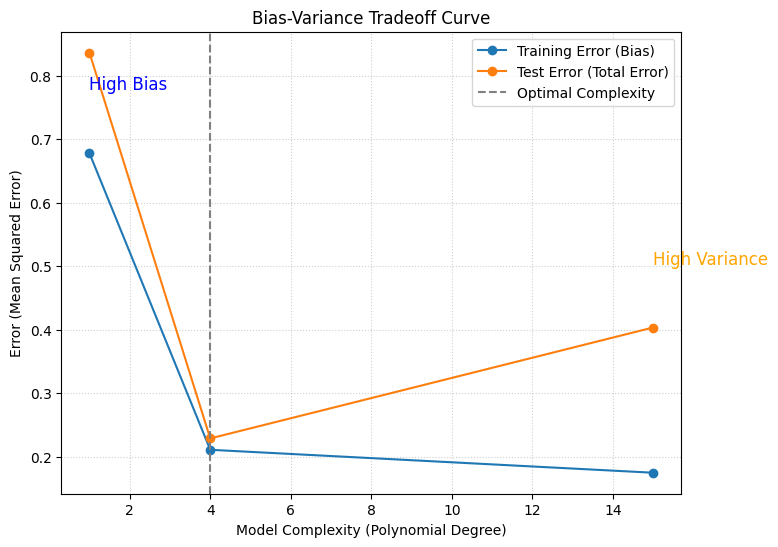

In [3]:
plt.figure(figsize=(8, 6))

# Plot the relationship between errors and complexity
plt.plot(degrees, train_errors, marker="o", label="Training Error (Bias)")
plt.plot(degrees, test_errors, marker="o", label="Test Error (Total Error)")
plt.axvline(x=4, color="gray", linestyle="--", label="Optimal Complexity")

plt.title("Bias-Variance Tradeoff Curve")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Error (Mean Squared Error)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.text(1, train_errors[0] + 0.1, "High Bias", color="blue", fontsize=12)
plt.text(15, test_errors[2] + 0.1, "High Variance", color="orange", fontsize=12)

plt.show()

### Key Takeaway from the Curve:

  * As complexity **increases**, **Training Error (Bias) decreases** (the model fits the training data better).
  * As complexity **increases**, **Test Error (Variance) initially decreases** and then **increases sharply** as the model starts overfitting.
  * The **optimal model** is found at the point of minimum Test Error.

## Techniques to Manage the Tradeoff

We manage the tradeoff by adjusting model complexity and data volume.

| Problem | Diagnosis | Solutions (Lowering Error Component) |
| :--- | :--- | :--- |
| **Underfitting** | High Bias, High Training Error | **Increase Model Complexity:** Add features, use non-linear models (e.g., Decision Trees, Polynomial Regression), decrease regularization ($\alpha$). |
| **Overfitting** | High Variance, Low Training Error but High Test Error | **Decrease Model Complexity:** Use simpler models, **Increase Regularization** ($\alpha$), **Feature Selection** (remove noisy features), **Collect More Training Data**, use **Ensemble Methods** (like Random Forests or Boosting). |